# Лабораторная работа 2: Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

Мы научились обрабатывать пропуски в данных для количественных (числовых) и категориальных признаков и масштабировать данные. Также мы научились преобразовывать категориальные признаки в числовые.

# Импорт бибилиотек

In [4]:
#импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#инструменты для предобработки данных
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

#настройка отображения
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style("whitegrid")

print("Библиотеки импортированы")

Библиотеки импортированы


# Загрузка и первичный анализ данных

Для выполнения задания был выбран датасет Titanic - Machine Learning from Disaster. Он содержит информацию о пассажирах и позволяет решать задачу классификации - предсказание выживаемости.

In [5]:
train_df = pd.read_csv('/Users/User/Desktop/Uni/6 семестр/Технологии машнного обучения/Лабораторная работа 2/titanic/train.csv')
test_df = pd.read_csv('/Users/User/Desktop/Uni/6 семестр/Технологии машнного обучения/Лабораторная работа 2/titanic/test.csv')
gender_submission = pd.read_csv('/Users/User/Desktop/Uni/6 семестр/Технологии машнного обучения/Лабораторная работа 2/titanic/gender_submission.csv')

print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")
print(f"Размер файла с предсказаниями: {gender_submission.shape}")

Размер обучающей выборки: (891, 12)
Размер тестовой выборки: (418, 11)
Размер файла с предсказаниями: (418, 2)


Объединим train и test, чтобы создать единое пространство признаков с одинковыми колонками. Это позволит одинаково заполнить пропуски и учесть все возможные значения. 

In [7]:
#объединяем train и test для совместной обработки (без целевой переменной-выживаемости)
#для корректного кодирования категорий, чтобы и в train, и в test были одинаковые категории
train_len = len(train_df)
test_len = len(test_df)

#уберем целевые переменные из объединения
y_train = train_df['Survived']
X_train = train_df.drop(['Survived', 'PassengerId'], axis=1)
X_test = test_df.drop('PassengerId', axis=1)

#объединим для обработки
combined = pd.concat([X_train, X_test], axis=0, ignore_index=True)
print(f"Размер объединенных данных для обработки: {combined.shape}")

Размер объединенных данных для обработки: (1309, 10)


In [ ]:
Просмотрим полученный датасет:

In [9]:
print("Первые строки: ", combined.head())
print("Типы колонок: ", combined.dtypes)


#проверка пропущенных значений
print("Пропуски: ", combined.isnull().sum())

total_count = combined.shape[0]
print('Всего строк: {}'.format(total_count))

Первые строки:     Pclass                                               Name     Sex   Age  \
0       3                            Braund, Mr. Owen Harris    male  22.0   
1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
2       3                             Heikkinen, Miss. Laina  female  26.0   
3       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
4       3                           Allen, Mr. William Henry    male  35.0   

   SibSp  Parch            Ticket     Fare Cabin Embarked  
0      1      0         A/5 21171   7.2500   NaN        S  
1      1      0          PC 17599  71.2833   C85        C  
2      0      0  STON/O2. 3101282   7.9250   NaN        S  
3      1      0            113803  53.1000  C123        S  
4      0      0            373450   8.0500   NaN        S  
Типы колонок:  Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str


# Обработка пропусков в данных

Проведем более детальный анализ пропусков:

Пропуски в данных:           Количество пропусков    Процент
Cabin                     1014  77.463713
Age                        263  20.091673
Embarked                     2   0.152788
Fare                         1   0.076394


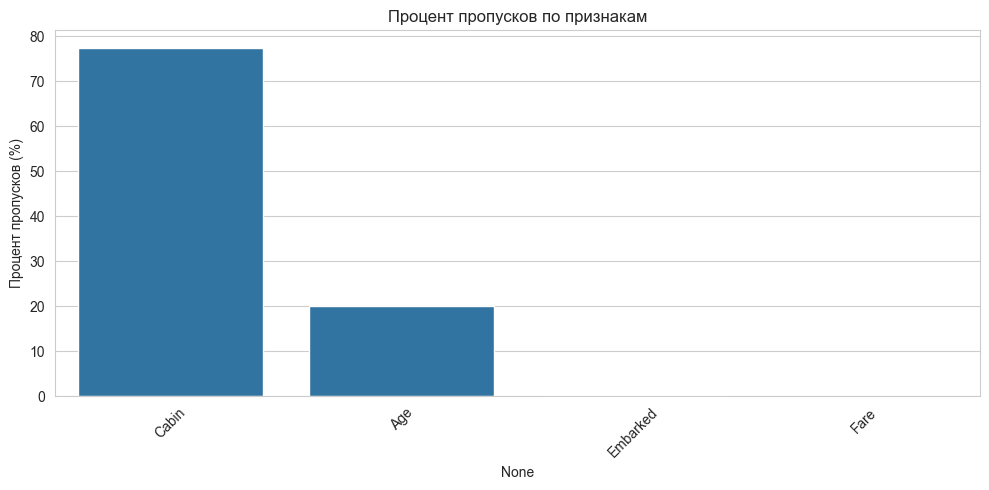

In [10]:
#анализ пропусков
null_counts = combined.isnull().sum()
null_percent = (null_counts / len(combined)) * 100
null_df = pd.DataFrame({
    'Количество пропусков': null_counts,
    'Процент': null_percent
})
null_df = null_df[null_df['Количество пропусков'] > 0].sort_values('Процент', ascending=False)
print("Пропуски в данных:", null_df)


#визуализируем
plt.figure(figsize=(10, 5))
sns.barplot(x=null_df.index, y='Процент', data=null_df)
plt.title('Процент пропусков по признакам')
plt.ylabel('Процент пропусков (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Стратегии обработки
1) Простые стратегии - удаление или заполнение нулями
Удаление колонок, содержащих пустые значения: res = data.dropna(axis=1, how='any')
Удаление строк, содержащих пустые значения: res = data.dropna(axis=0, how='any')

Удаление может производиться для группы строк или колонок. В нашем случае имеет смысл удалить признак с наибольшим количеством пропусков-Cabin (>50%).



In [11]:
combined_clean = combined.drop('Cabin', axis=1)
print(f"Размер после удаления Cabin: {combined_clean.shape}")
print(f"Оставшиеся колонки: {combined_clean.columns.tolist()}")

Размер после удаления Cabin: (1309, 9)
Оставшиеся колонки: ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


2) "Внедрение значений"-импьютация (imputation)

Заполним пропуски в Age(числовой признак) и Embarked(категориальный признак). 

In [12]:
#проверим значения в Embarked
print("Уникальные значения в Embarked до обработки:")
print(combined_clean['Embarked'].value_counts(dropna=False))
print(f"Количество пропусков: {combined_clean['Embarked'].isnull().sum()}")

#заполняем пропуски наиболее частым значением(модой)
embarked_imputer = SimpleImputer(strategy='most_frequent')
combined_clean['Embarked'] = embarked_imputer.fit_transform(combined_clean[['Embarked']]).ravel()

print("\nУникальные значения в Embarked после обработки:")
print(combined_clean['Embarked'].value_counts(dropna=False))

Уникальные значения в Embarked до обработки:
Embarked
S      914
C      270
Q      123
NaN      2
Name: count, dtype: int64
Количество пропусков: 2

Уникальные значения в Embarked после обработки:
Embarked
S    916
C    270
Q    123
Name: count, dtype: int64


Попробуем несколько методов заполнения числовых признаков-константой, медианой, средним.

Исходные данные Age (первые 20 строк с пропусками):


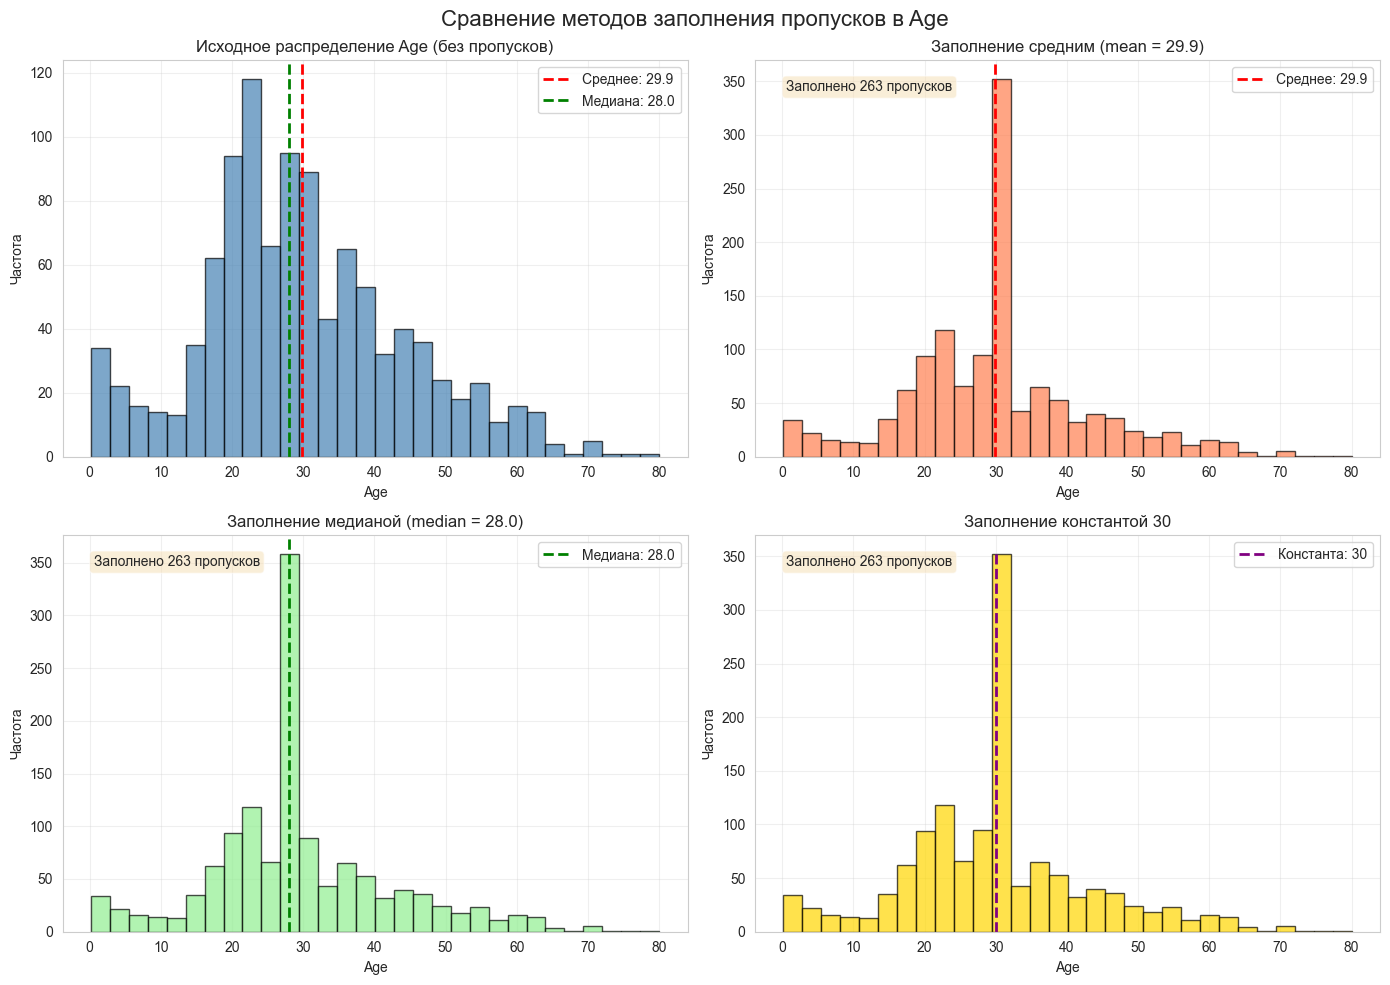


Сравнение значений (первые 20 строк):

Статистика:
Среднее исходных данных (без пропусков): 29.88
Медиана исходных данных (без пропусков): 28.00
Количество заполненных пропусков: 263

Вывод: Медиана (28.00) более устойчива к выбросам и лучше сохраняет центральную тенденцию

Пропусков в Age после обработки: 0


In [13]:
#сделаем копию для демонстрации
age_data = combined_clean[['Age']].copy()
print("Исходные данные Age (первые 20 строк с пропусками):")
#покажем первые 20 строк, включая пропуски
age_data_with_index = age_data.reset_index(drop=True)
age_data_with_index.head(20)

#функция для демонстрации разных методов заполнения+визуализация
def demonstrate_age_imputation_with_plots(data):
    """
    демонстрирукм различные методы заполнения пропусков и строим гистограммы
    для сравнения влияния на распределение данных
    """
    #создаем копию для экспериментов
    age_demo = data.copy()
    
    #сохраняем исходные данные без пропусков для сравнения
    age_original_non_null = age_demo.dropna().values
    
    #метод 1-заполнение средним
    imputer_mean = SimpleImputer(strategy='mean')
    age_mean = imputer_mean.fit_transform(age_demo)
    mean_value = imputer_mean.statistics_[0]
    
    #метод 2-заполнение медианой
    imputer_median = SimpleImputer(strategy='median')
    age_median = imputer_median.fit_transform(age_demo)
    median_value = imputer_median.statistics_[0]
    
    #метод 3-заполнение константой (30 лет)
    const_value = 30
    imputer_constant = SimpleImputer(strategy='constant', fill_value=const_value)
    age_constant = imputer_constant.fit_transform(age_demo)
    
    #создаем фрейм для сравнения значений
    comparison = pd.DataFrame({
        'Исходный': age_demo['Age'].values,
        'Заполнено средним': age_mean.ravel(),
        'Заполнено медианой': age_median.ravel(),
        f'Заполнено константой {const_value}': age_constant.ravel()
    })
    
    #визуализация распределений
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Сравнение методов заполнения пропусков в Age', fontsize=16)
    
    #исходное распределение (без пропусков)
    axes[0, 0].hist(age_original_non_null, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0, 0].axvline(age_original_non_null.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {age_original_non_null.mean():.1f}')
    axes[0, 0].axvline(np.median(age_original_non_null), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(age_original_non_null):.1f}')
    axes[0, 0].set_title('Исходное распределение Age (без пропусков)')
    axes[0, 0].set_xlabel('Age')
    axes[0, 0].set_ylabel('Частота')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    #заполнение средним
    axes[0, 1].hist(age_mean, bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[0, 1].axvline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_value:.1f}')
    axes[0, 1].set_title(f'Заполнение средним (mean = {mean_value:.1f})')
    axes[0, 1].set_xlabel('Age')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    #подсчет заполненных значений для аннотации
    n_missing = age_demo['Age'].isnull().sum()
    axes[0, 1].text(0.05, 0.95, f'Заполнено {n_missing} пропусков', 
                    transform=axes[0, 1].transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    #заполнение медианой
    axes[1, 0].hist(age_median, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1, 0].axvline(median_value, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_value:.1f}')
    axes[1, 0].set_title(f'Заполнение медианой (median = {median_value:.1f})')
    axes[1, 0].set_xlabel('Age')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 0].text(0.05, 0.95, f'Заполнено {n_missing} пропусков', 
                    transform=axes[1, 0].transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    #заполнение константой
    axes[1, 1].hist(age_constant, bins=30, alpha=0.7, color='gold', edgecolor='black')
    
    #показываем пик от заполненных значений
    max_count = np.max(np.histogram(age_constant, bins=30)[0])
    axes[1, 1].plot([const_value, const_value], [0, max_count], 
                    color='purple', linestyle='--', linewidth=2, label=f'Константа: {const_value}')
    axes[1, 1].set_title(f'Заполнение константой {const_value}')
    axes[1, 1].set_xlabel('Age')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 1].text(0.05, 0.95, f'Заполнено {n_missing} пропусков', 
                    transform=axes[1, 1].transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return comparison, {'mean': mean_value, 'median': median_value, 'constant': const_value, 'n_missing': n_missing}

#демонстрация с визуализацией
comparison_df, stats = demonstrate_age_imputation_with_plots(age_data)

print("\nСравнение значений (первые 20 строк):")
comparison_df

print(f"\nСтатистика:")
print(f"Среднее исходных данных (без пропусков): {stats['mean']:.2f}")
print(f"Медиана исходных данных (без пропусков): {stats['median']:.2f}")
print(f"Количество заполненных пропусков: {stats['n_missing']}")
print(f"\nВывод: Медиана ({stats['median']:.2f}) более устойчива к выбросам и лучше сохраняет центральную тенденцию")

#выбираем метод с медианой (более устойчив к выбросам)
age_imputer = SimpleImputer(strategy='median')
combined_clean['Age'] = age_imputer.fit_transform(combined_clean[['Age']]).ravel()

print(f"\nПропусков в Age после обработки: {combined_clean['Age'].isnull().sum()}")

Несмотря на то, что метод с медианой более устойчив в выбросам, чем среднее значение, после заполнения пропусков гистограмма распределения измениал свой внешний вид довольно сильно.

Следующим шагом добавим флаги пропуска для Age (как как провент пропуска больше, чем для Embarked):

In [25]:
#добавляем флаг пропуска для Age
indicator = MissingIndicator()
age_missing_mask = indicator.fit_transform(combined_clean[['Age_original']] if 'Age_original' in combined_clean.columns 
                                          else combined_clean[['Age']])

#восстанавливаем исходные данные с пропусками для создания флага
#(в нашем случае мы уже заполнили, поэтому используем исходные из combined)
age_original = combined['Age'].copy()
age_missing_flag = age_original.isnull().astype(int)
combined_clean['Age_missing_flag'] = age_missing_flag

print("Первые 10 строк с флагом пропуска Age:")
pd.DataFrame({
    'Age (заполненное)': combined_clean['Age'].head(10),
    'Был пропуск': combined_clean['Age_missing_flag'].head(10)
})

Первые 10 строк с флагом пропуска Age:


,Age (заполненное),Был пропуск
0,22.0,0
1,38.0,0
2,26.0,0
3,35.0,0
4,35.0,0
5,28.0,1
6,54.0,0
7,2.0,0
8,27.0,0
9,14.0,0


#Преобразование категориальных признаков в числовые

Опробуем использование LabelEncoder на признаке "Пол", а One-Hot Encoding (набором бинарных значений) на признаке "Embarked":

In [27]:
#LabelEncoder для пола
le_sex = LabelEncoder()
combined_clean['Sex_Label'] = le_sex.fit_transform(combined_clean['Sex'])

print("Результат Label Encoding для Sex:")
print(pd.DataFrame({
    'Sex': combined_clean['Sex'].head(10),
    'Sex_Label': combined_clean['Sex_Label'].head(10)
}))
print(f"\nСоответствие: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

#удаляем исходный столбец
combined_clean = combined_clean.drop('Sex', axis=1)

Результат Label Encoding для Sex:
      Sex  Sex_Label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1
5    male          1
6    male          1
7    male          1
8  female          0
9  female          0

Соответствие: {'female': 0, 'male': 1}


Для Embarked существует 3 варианта-C, S и Q, может возникнуть проблема линейной зависимости и нам придется отбросить один из вариантов: 

In [31]:


#создаем пример данных
data = pd.DataFrame({
    'Embarked': ['S', 'C', 'Q', 'S', 'C', 'Q']
})

print("Исходные данные:")
print(data)

#One-Hot Encoding со всеми категориями
dummies_all = pd.get_dummies(data, columns=['Embarked'])
print("\nOne-Hot со всеми категориями:")
print(dummies_all)

#демонстрация линейной зависимости
print("\nПроверка линейной зависимости:")
print("Embarked_S + Embarked_C + Embarked_Q = 1 для каждой строки")
for i in range(len(dummies_all)):
    sum_cols = dummies_all.loc[i, ['Embarked_S', 'Embarked_C', 'Embarked_Q']].sum()
    print(f"Строка {i}: {sum_cols}")

Исходные данные:
  Embarked
0        S
1        C
2        Q
3        S
4        C
5        Q

One-Hot со всеми категориями:
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False        True       False
3       False       False        True
4        True       False       False
5       False        True       False

Проверка линейной зависимости:
Embarked_S + Embarked_C + Embarked_Q = 1 для каждой строки
Строка 0: 1
Строка 1: 1
Строка 2: 1
Строка 3: 1
Строка 4: 1
Строка 5: 1


In [29]:
#OneHotEncoder для embarked
ohe_embarked = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' для избежания мультиколлинеарности
embarked_encoded = ohe_embarked.fit_transform(combined_clean[['Embarked']])

#получаем названия новых колонок
embarked_categories = ohe_embarked.categories_[0][1:]  # пропускаем первую категорию
embarked_cols = [f'Embarked_{cat}' for cat in embarked_categories]

#создаем фрейм с закодированными признаками
embarked_df = pd.DataFrame(embarked_encoded, columns=embarked_cols, index=combined_clean.index)

#добавляем к основным данным
combined_clean = pd.concat([combined_clean, embarked_df], axis=1)
combined_clean = combined_clean.drop('Embarked', axis=1)

print("Результат One-Hot Encoding для Embarked (первые 10 строк):")
combined_clean[embarked_cols].head(10)

Результат One-Hot Encoding для Embarked (первые 10 строк):


,Embarked_Q,Embarked_S
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,1.0,0.0
6,0.0,1.0
7,0.0,1.0
8,0.0,1.0
9,0.0,0.0


#Масштабирование числовых признаков

Термины "масштабирование" и "нормализация" часто используются как синонимы, но это неверно. Масштабирование предполагает изменение диапазона измерения величины, а нормализация - изменение распределения этой величины. В этом разделе рассматривается только масштабирование.

Если признаки лежат в различных диапазонах, то необходимо их нормализовать. Как правило, применяют два подхода:
- MinMax масштабирование:
$$ x_{новый} = \frac{x_{старый} - min(X)}{max(X)-min(X)} $$

В этом случае значения лежат в диапазоне от 0 до 1.
- Масштабирование данных на основе [Z-оценки]:
$$ x_{новый} = \frac{x_{старый} - AVG(X) }{\sigma(X)} $$

В этом случае большинство значений попадает в диапазон от -3 до 3.

где $X$ - матрица объект-признак, $AVG(X)$ - среднее значение, $\sigma$ - среднеквадратичное отклонение.

In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#определяем числовые признаки для масштабирования
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']


print("\nСтатистика числовых признаков до масштабирования:")

combined_clean[numeric_features].describe()


Статистика числовых признаков до масштабирования:


,Age,Fare,SibSp,Parch
count,1309.000000,1308.000000,1309.000000,1309.000000
mean,29.503186,33.295479,0.498854,0.385027
std,12.905241,51.758668,1.041658,0.865560
min,0.170000,0.000000,0.000000,0.000000
25%,22.000000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.275000,1.000000,0.000000
max,80.000000,512.329200,8.000000,9.000000


In [41]:
#MinMaxScaler-масштабирование в диапазон [0, 1]
scaler_minmax = MinMaxScaler()
combined_minmax = scaler_minmax.fit_transform(combined_clean[numeric_features])

#StandardScaler-стандартизация
scaler_standard = StandardScaler()
combined_standard = scaler_standard.fit_transform(combined_clean[numeric_features])

#Создаем фрейм для сравнения
scaling_comparison = pd.DataFrame({
    #age
    'Age_original': combined_clean['Age'],
    'Age_minmax': combined_minmax[:, 0],
    'Age_standard': combined_standard[:, 0],
    
    #fare
    'Fare_original': combined_clean['Fare'],
    'Fare_minmax': combined_minmax[:, 1],
    'Fare_standard': combined_standard[:, 1],
    
    #sibsp
    'SibSp_original': combined_clean['SibSp'],
    'SibSp_minmax': combined_minmax[:, 2],
    'SibSp_standard': combined_standard[:, 2],
    
    #parch
    'Parch_original': combined_clean['Parch'],
    'Parch_minmax': combined_minmax[:, 3],
    'Parch_standard': combined_standard[:, 3]
})

print("\nСравнение методов масштабирования (первые 10 строк):", scaling_comparison.head(10))




Сравнение методов масштабирования (первые 10 строк):    Age_original  Age_minmax  Age_standard  Fare_original  Fare_minmax  \
0          22.0    0.273456     -0.581628         7.2500     0.014151   
1          38.0    0.473882      0.658652        71.2833     0.139136   
2          26.0    0.323563     -0.271558         7.9250     0.015469   
3          35.0    0.436302      0.426099        53.1000     0.103644   
4          35.0    0.436302      0.426099         8.0500     0.015713   
5          28.0    0.348616     -0.116523         8.4583     0.016510   
6          54.0    0.674308      1.898932        51.8625     0.101229   
7           2.0    0.022924     -2.131979        21.0750     0.041136   
8          27.0    0.336089     -0.194041        11.1333     0.021731   
9          14.0    0.173243     -1.201768        30.0708     0.058694   

   Fare_standard  SibSp_original  SibSp_minmax  SibSp_standard  \
0      -0.503402               1         0.125        0.481288   
1       0.

В качестве признаков, на которых мы проведем масштабирование на признаках Age и Fare.

In [43]:
numeric_features_to_scale = ['Age', 'Fare']

print(f"\nПризнаки для масштабирования: {numeric_features_to_scale}")
print(f"Признаки без масштабирования: ['SibSp', 'Parch']")


Признаки для масштабирования: ['Age', 'Fare']
Признаки без масштабирования: ['SibSp', 'Parch']


Статистика до масштабирования
               Age         Fare
count  1309.000000  1308.000000
mean     29.503186    33.295479
std      12.905241    51.758668
min       0.170000     0.000000
25%      22.000000     7.895800
50%      28.000000    14.454200
75%      35.000000    31.275000
max      80.000000   512.329200


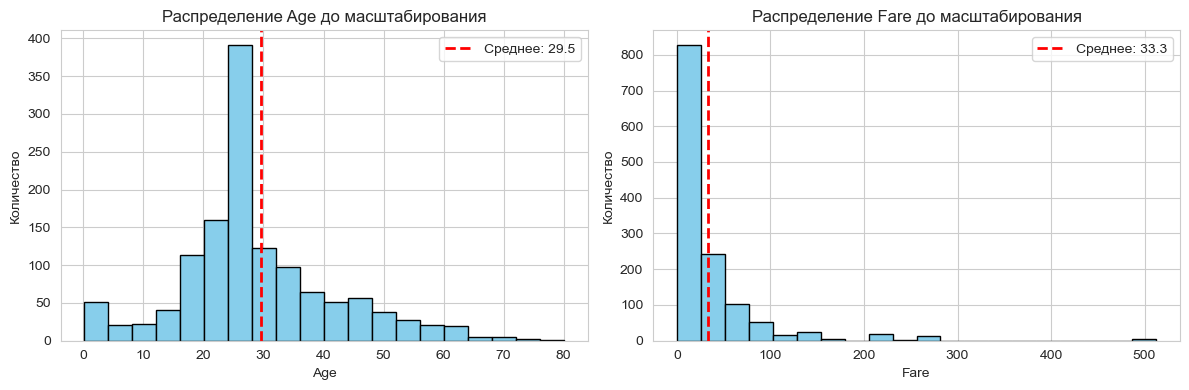

In [51]:
print("Статистика до масштабирования")
original_stats = combined_clean[numeric_features_to_scale].describe()
print(original_stats)

#визуализируем исходные данные
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#age
axes[0].hist(combined_clean['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(combined_clean['Age'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {combined_clean["Age"].mean():.1f}')
axes[0].set_title('Распределение Age до масштабирования')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Количество')
axes[0].legend()

#fare
axes[1].hist(combined_clean['Fare'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[1].axvline(combined_clean['Fare'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {combined_clean["Fare"].mean():.1f}')
axes[1].set_title('Распределение Fare до масштабирования')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()


Используем StandardScaler:

In [53]:
scaler = StandardScaler()

#применяем масштабирование
scaled_features = scaler.fit_transform(combined_clean[numeric_features_to_scale])

#создаем фрейм с результатами
scaled_df = pd.DataFrame(
    scaled_features,
    columns=[f'{col}_scaled' for col in numeric_features_to_scale],
    index=combined_clean.index
)

print(f"\nСреднее после масштабирования: {scaled_df.mean().round(4).tolist()}")
print(f"Стд отклонение после масштабирования: {scaled_df.std().round(4).tolist()}")
#Должно быть близко к 0 и 1 соответственно


Среднее после масштабирования: [0.0, -0.0]
Стд отклонение после масштабирования: [1.0004, 1.0004]
(Должно быть близко к 0 и 1 соответственно)


Первые 5 строк после добавления:


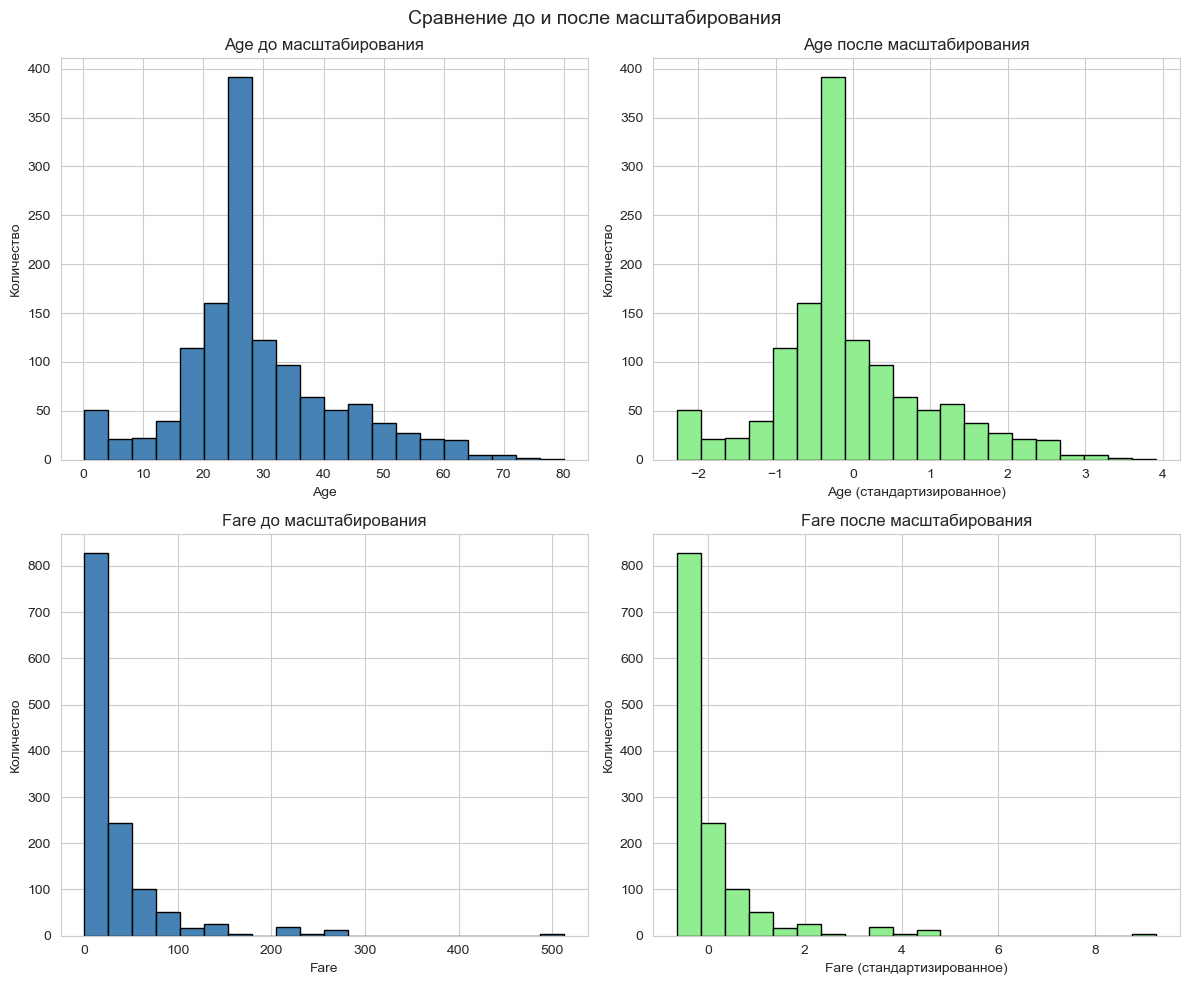

In [59]:
#добавляем масштабированные признаки в основной фрейм
for col in numeric_features_to_scale:
    combined_clean[f'{col}_scaled'] = scaled_df[f'{col}_scaled'].values

print("Первые 5 строк после добавления:")
combined_clean[['Age', 'Age_scaled', 'Fare', 'Fare_scaled']].head()


#создаем гистограммы для сравнения
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Сравнение до и после масштабирования', fontsize=14)

#age до
axes[0, 0].hist(combined_clean['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Age до масштабирования')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Количество')

#age после
axes[0, 1].hist(combined_clean['Age_scaled'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Age после масштабирования')
axes[0, 1].set_xlabel('Age (стандартизированное)')
axes[0, 1].set_ylabel('Количество')

#fare до
axes[1, 0].hist(combined_clean['Fare'], bins=20, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Fare до масштабирования')
axes[1, 0].set_xlabel('Fare')
axes[1, 0].set_ylabel('Количество')

#fare после
axes[1, 1].hist(combined_clean['Fare_scaled'], bins=20, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Fare после масштабирования')
axes[1, 1].set_xlabel('Fare (стандартизированное)')
axes[1, 1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [63]:

print("Параметры масштабирования")


#сохраняем параметры 
scaler_params = {
    'Age': {
        'mean': scaler.mean_[0],
        'std': np.sqrt(scaler.var_[0]),
    },
    'Fare': {
        'mean': scaler.mean_[1],
        'std': np.sqrt(scaler.var_[1]),
    }
}

params_df = pd.DataFrame(scaler_params).round(4)
print(params_df)

#обратное преобразование
age_sample = combined_clean['Age_scaled'].iloc[0]
age_original = scaler.inverse_transform([[age_sample, 0]])[0][0]
print(f"\nПример обратного преобразования:")
print(f"Age_scaled = {age_sample:.4f} → Age = {age_original:.2f}")

Параметры масштабирования
          Age     Fare
mean  29.5032  33.2955
std   12.9003  51.7389

Пример обратного преобразования:
Age_scaled = -0.5816 → Age = 22.00



#Вывод

В ходе выполнения лабораторной работы была проведена полная предобработка датасета Titanic, включающая обработку пропусков, кодирование категориальных признаков и масштабирование числовых данных. Анализ показал наличие пропусков в трех признаках: Age (20%), Cabin (77%) и Embarked (2 пропуска). Признак Cabin был удален из-за критического количества пропусков, Embarked заполнен модой, а для Age проведен сравнительный анализ методов заполнения, по результатам которого выбрана медиана как наиболее устойчивая к выбросам. Для Age также добавлен бинарный флаг пропуска, позволяющий модели учитывать факт отсутствия данных. Категориальные признаки преобразованы в числовой формат: Sex закодирован методом Label Encoding, Embarked-методом One-Hot Encoding с исключением первой категории для избежания мультиколлинеарности. Для числовых признаков Age и Fare, имеющих разные масштабы и выбросы, применен StandardScaler как более устойчивый метод стандартизации, при этом параметры масштабирования сохранены для обратного преобразования тестовых данных. В результате всех преобразований получен набор данных без пропусков, с полностью числовыми признаками, приведенными к сопоставимому масштабу, что делает его готовым для построения моделей машинного обучения.